In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.shape

(42000, 785)

In [5]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
7642,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import matplotlib.pyplot as plt

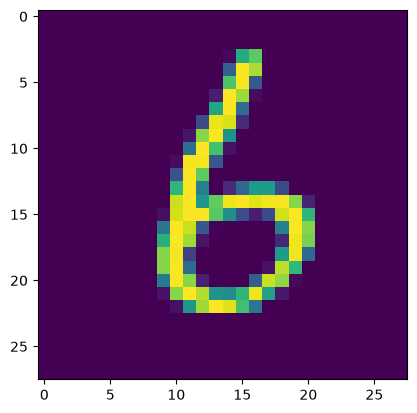

In [12]:
plt.imshow(df.iloc[7642,1:].values.reshape(28, 28))

In [13]:
from sklearn.preprocessing import StandardScaler

In [16]:
X = df.iloc[:, 1:]
Y = df.iloc[:,0]

In [18]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
scaler = StandardScaler()

In [20]:
X = scaler.fit_transform(X)

In [21]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(42000, 784))

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA()

In [36]:
X_transformed = pca.fit_transform(X)

In [37]:
X_transformed.shape

(42000, 784)

In [46]:
pca.explained_variance_
# These are the eigen values for each eigen vector

array([4.06964787e+01, 2.91114657e+01, 2.67833371e+01, 2.08147194e+01,
       1.81000206e+01, 1.57876737e+01, 1.38244007e+01, 1.25432643e+01,
       1.10638975e+01, 1.00889267e+01, 9.63617203e+00, 8.65579470e+00,
       8.04120472e+00, 7.88086691e+00, 7.43637560e+00, 7.16743699e+00,
       6.73538375e+00, 6.61651973e+00, 6.42354578e+00, 6.26826675e+00,
       5.93960379e+00, 5.74928832e+00, 5.48826880e+00, 5.32649477e+00,
       5.15217038e+00, 4.94730998e+00, 4.88853571e+00, 4.70777145e+00,
       4.46528559e+00, 4.36351702e+00, 4.32543150e+00, 4.22712324e+00,
       4.08726514e+00, 4.06176768e+00, 3.99903435e+00, 3.86804997e+00,
       3.81925839e+00, 3.71256507e+00, 3.57437538e+00, 3.45887625e+00,
       3.41436841e+00, 3.36945857e+00, 3.25693182e+00, 3.24008824e+00,
       3.18312949e+00, 3.16286640e+00, 3.14244041e+00, 3.09287815e+00,
       3.06368054e+00, 3.02342271e+00, 2.96849737e+00, 2.91830693e+00,
       2.84948896e+00, 2.82806029e+00, 2.79589667e+00, 2.76696531e+00,
      

In [43]:
pca.components_.shape
# here we get the 784 vectors.

(784, 784)

## The data is transformed into 784 dimansion, actually we did not given any parameters to convert it to anythoer dimension.  
## Lets just try to convert it into 3D

In [47]:
pca1 = PCA(n_components=3)

In [48]:
X_3d = pca1.fit_transform(X)

In [51]:
X_3d.shape

(42000, 3)

In [52]:
pca1.explained_variance_

array([40.69647875, 29.11146566, 26.7833371 ])

In [53]:
pca1.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(3, 784))

#### These are 3 eigen values and eigen vectors.

# How to choose optimul `n_components`

Calculate the percentage of info retaintayion of each eigen value, try to go for 90% atleast for best model performance

In [75]:
pca.explained_variance_ratio_*100

array([5.74795336e+00, 4.11169103e+00, 3.78286715e+00, 2.93986212e+00,
       2.55643921e+00, 2.22984433e+00, 1.95255247e+00, 1.77160531e+00,
       1.56266017e+00, 1.42495571e+00, 1.36100884e+00, 1.22254076e+00,
       1.13573634e+00, 1.11309029e+00, 1.05031053e+00, 1.01232575e+00,
       9.51302738e-01, 9.34514435e-01, 9.07258876e-01, 8.85327331e-01,
       8.38907114e-01, 8.12027039e-01, 7.75160752e-01, 7.52311857e-01,
       7.27690355e-01, 6.98755959e-01, 6.90454706e-01, 6.64923638e-01,
       6.30675038e-01, 6.16301289e-01, 6.10922106e-01, 5.97037089e-01,
       5.77283590e-01, 5.73682340e-01, 5.64821911e-01, 5.46321734e-01,
       5.39430432e-01, 5.24361113e-01, 5.04843259e-01, 4.88530211e-01,
       4.82243943e-01, 4.75900896e-01, 4.60007666e-01, 4.57628685e-01,
       4.49583855e-01, 4.46721905e-01, 4.43836948e-01, 4.36836795e-01,
       4.32712937e-01, 4.27026938e-01, 4.19269307e-01, 4.12180430e-01,
       4.02460610e-01, 3.99434033e-01, 3.94891257e-01, 3.90805004e-01,
      

In [76]:
cumsum = 0
for i, val in enumerate(pca.explained_variance_ratio_):
    cumsum += val*100
    if cumsum >= 90:
        print(i, cumsum)
        break

228 90.0458791512449


# so on 228 and more n_components are safe to use 
## The 228 have 90% of variance explained!